In [ ]:
# Cell 1: Mount Drive and load both datasets
from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/financial-news-sentiment-stock-predictor'
DATA_PATH = f'{PROJECT_PATH}/data'
PLOTS_PATH = f'{PROJECT_PATH}/plots'

import pandas as pd
import numpy as np
import os

# Load price data
price_data = pd.read_csv(f'{DATA_PATH}/price_data.csv')
price_data['Date'] = pd.to_datetime(price_data['Date'])

# Load sentiment features
sentiment_df = pd.read_csv(f'{DATA_PATH}/sentiment_features.csv')
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

print(f"Price data shape: {price_data.shape}")
print(f"Sentiment data shape: {sentiment_df.shape}")
print(f"\nTickers in price data: "
      f"{sorted(price_data['ticker'].unique().tolist())}")
print(f"Tickers in sentiment data: "
      f"{sorted(sentiment_df['ticker'].unique().tolist())}")
print(f"\nPrice date range: {price_data['Date'].min().date()} "
      f"to {price_data['Date'].max().date()}")
print(f"Sentiment date range: {sentiment_df['date'].min().date()} "
      f"to {sentiment_df['date'].max().date()}")

Mounted at /content/drive
Price data shape: (6275, 8)
Sentiment data shape: (121, 7)

Tickers in price data: ['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'TSLA']
Tickers in sentiment data: ['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'TSLA']

Price date range: 2021-06-14 to 2026-06-11
Sentiment date range: 2026-05-17 to 2026-06-14


In [ ]:
# Cell 2: Compute technical indicators for all 5 tickers
!pip install ta -q

import ta
import warnings
warnings.filterwarnings('ignore')

TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']

def compute_technical_indicators(df):
    """Compute all technical indicators for a single ticker's data."""
    df = df.copy().sort_values('Date').reset_index(drop=True)

    # --- Moving Averages ---
    df['sma_10'] = ta.trend.sma_indicator(df['Close'], window=10)
    df['sma_20'] = ta.trend.sma_indicator(df['Close'], window=20)
    df['sma_50'] = ta.trend.sma_indicator(df['Close'], window=50)
    df['ema_10'] = ta.trend.ema_indicator(df['Close'], window=10)
    df['ema_20'] = ta.trend.ema_indicator(df['Close'], window=20)

    # Price relative to moving averages (scale-invariant ratios)
    df['close_to_sma20'] = df['Close'] / df['sma_20']
    df['close_to_sma50'] = df['Close'] / df['sma_50']

    # --- Momentum ---
    df['rsi_14'] = ta.momentum.rsi(df['Close'], window=14)
    df['rsi_from_70'] = df['rsi_14'] - 70
    df['rsi_from_30'] = df['rsi_14'] - 30

    # --- MACD ---
    df['macd'] = ta.trend.macd(df['Close'])
    df['macd_signal'] = ta.trend.macd_signal(df['Close'])
    df['macd_diff'] = ta.trend.macd_diff(df['Close'])

    # --- Bollinger Bands ---
    df['bb_high'] = ta.volatility.bollinger_hband(
        df['Close'], window=20)
    df['bb_low'] = ta.volatility.bollinger_lband(
        df['Close'], window=20)
    df['bb_width'] = (df['bb_high'] - df['bb_low']) / \
                      ta.trend.sma_indicator(df['Close'], window=20)
    df['bb_position'] = (df['Close'] - df['bb_low']) / \
                         (df['bb_high'] - df['bb_low'])

    # --- Returns & Volatility ---
    df['daily_return'] = df['Close'].pct_change()
    df['volatility_10'] = df['daily_return'].rolling(window=10).std()

    # --- Volume ---
    df['volume_change'] = df['Volume'].pct_change()
    df['volume_ratio'] = df['Volume'] / \
                          df['Volume'].rolling(window=20).mean()

    return df

# Apply to each ticker separately
ticker_dfs = []
for ticker in TICKERS:
    subset = price_data[price_data['ticker'] == ticker].copy()
    subset_with_indicators = compute_technical_indicators(subset)
    ticker_dfs.append(subset_with_indicators)
    print(f"{ticker}: {len(subset_with_indicators)} rows, "
          f"{len(subset_with_indicators.columns)} columns")

# Combine all tickers back into one DataFrame
price_features = pd.concat(ticker_dfs, ignore_index=True)
price_features = price_features.sort_values(
    ['ticker', 'Date']).reset_index(drop=True)

print(f"\nCombined shape: {price_features.shape}")
print(f"New indicator columns added: "
      f"{len(price_features.columns) - len(price_data.columns)}")

  Preparing metadata (setup.py) ... done
AAPL: 1255 rows, 29 columns
MSFT: 1255 rows, 29 columns
GOOGL: 1255 rows, 29 columns
AMZN: 1255 rows, 29 columns
TSLA: 1255 rows, 29 columns

Combined shape: (6275, 29)
New indicator columns added: 21


In [ ]:
# Cell 3: Drop NaN rows created by rolling window indicators
print("NaN counts before dropping:")
print(price_features.isnull().sum())

# Drop NaN rows within each ticker separately
price_features_clean = price_features.groupby('ticker').apply(
    lambda x: x.dropna()).reset_index(drop=True)

# Verify rows remaining per ticker
print(f"\nRows per ticker after dropping NaN:")
for ticker in TICKERS:
    subset = price_features_clean[
        price_features_clean['ticker'] == ticker]
    print(f"  {ticker}: {len(subset)} rows | "
          f"{subset['Date'].min().date()} to "
          f"{subset['Date'].max().date()}")

print(f"\nTotal rows before: {len(price_features)}")
print(f"Total rows after: {len(price_features_clean)}")
print(f"Rows dropped: {len(price_features) - len(price_features_clean)}")

NaN counts before dropping:
Date                0
Close               0
High                0
Low                 0
Open                0
Volume              0
ticker              0
target              0
sma_10             45
sma_20             95
sma_50            245
ema_10             45
ema_20             95
close_to_sma20     95
close_to_sma50    245
rsi_14             65
rsi_from_70        65
rsi_from_30        65
macd              125
macd_signal       165
macd_diff         165
bb_high            95
bb_low             95
bb_width           95
bb_position        95
daily_return        5
volatility_10      50
volume_change       5
volume_ratio       95
dtype: int64

Rows per ticker after dropping NaN:
  AAPL: 1206 rows | 2021-08-23 to 2026-06-11
  MSFT: 1206 rows | 2021-08-23 to 2026-06-11
  GOOGL: 1206 rows | 2021-08-23 to 2026-06-11
  AMZN: 1206 rows | 2021-08-23 to 2026-06-11
  TSLA: 1206 rows | 2021-08-23 to 2026-06-11

Total rows before: 6275
Total rows after: 6030
Rows dropp

In [ ]:
# Cell 4: Encode ticker as a numeric feature for XGBoost
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
price_features_clean['ticker_encoded'] = le.fit_transform(
    price_features_clean['ticker'])

print("Ticker encoding mapping:")
for ticker, code in zip(le.classes_,
                         range(len(le.classes_))):
    print(f"  {ticker} → {code}")

print(f"\nTicker encoded value counts:")
print(price_features_clean['ticker_encoded'].value_counts().sort_index())

Ticker encoding mapping:
  AAPL → 0
  AMZN → 1
  GOOGL → 2
  MSFT → 3
  TSLA → 4

Ticker encoded value counts:
ticker_encoded
0    1206
1    1206
2    1206
3    1206
4    1206
Name: count, dtype: int64


In [7]:
# Cell 5: Merge technical features with sentiment data
# Rename sentiment date column to match price data
sentiment_df = sentiment_df.rename(columns={'date': 'Date'})

# Merge on both Date AND ticker - critical for multi-stock
features_df = price_features_clean.merge(
    sentiment_df,
    on=['Date', 'ticker'],
    how='left'
)

# Fill missing sentiment with neutral values
sentiment_cols = ['avg_sentiment', 'sentiment_std',
                  'news_count', 'positive_count', 'negative_count']

fill_values = {
    'avg_sentiment': 0.0,
    'sentiment_std': 0.0,
    'news_count': 0,
    'positive_count': 0,
    'negative_count': 0
}
features_df[sentiment_cols] = features_df[sentiment_cols].fillna(
    fill_values)

# Verify merge quality
print("Merge results:")
print(f"Shape after merge: {features_df.shape}")
print(f"\nNull check: {features_df.isnull().sum().sum()} total nulls")

print(f"\nSentiment coverage per ticker:")
for ticker in TICKERS:
    subset = features_df[features_df['ticker'] == ticker]
    real_days = (subset['news_count'] > 0).sum()
    total_days = len(subset)
    print(f"  {ticker}: {real_days} real sentiment days / "
          f"{total_days} total trading days "
          f"({real_days/total_days*100:.1f}%)")

print(f"\nOverall sentiment coverage:")
total_real = (features_df['news_count'] > 0).sum()
print(f"  {total_real} real sentiment rows / "
      f"{len(features_df)} total rows "
      f"({total_real/len(features_df)*100:.1f}%)")

Merge results:
Shape after merge: (6030, 35)

Null check: 0 total nulls

Sentiment coverage per ticker:
  AAPL: 17 real sentiment days / 1206 total trading days (1.4%)
  MSFT: 12 real sentiment days / 1206 total trading days (1.0%)
  GOOGL: 17 real sentiment days / 1206 total trading days (1.4%)
  AMZN: 17 real sentiment days / 1206 total trading days (1.4%)
  TSLA: 18 real sentiment days / 1206 total trading days (1.5%)

Overall sentiment coverage:
  81 real sentiment rows / 6030 total rows (1.3%)


In [8]:
# Cell 6: Drop raw price columns, keep only derived features
raw_cols_to_drop = ['Close', 'High', 'Low', 'Open',
                    'Volume', 'bb_high', 'bb_low']

features_df = features_df.drop(columns=raw_cols_to_drop)

# Final column check
print("Final feature columns:")
print([c for c in features_df.columns
       if c not in ['Date', 'ticker', 'target']])
print(f"\nTotal feature columns: "
      f"{len([c for c in features_df.columns if c not in ['Date', 'ticker', 'target']])}")
print(f"\nFinal dataset shape: {features_df.shape}")
print(f"Date range: {features_df['Date'].min().date()} "
      f"to {features_df['Date'].max().date()}")
print(f"\nTarget distribution:")
print(features_df['target'].value_counts())
print(f"\nClass balance:")
print(features_df['target'].value_counts(normalize=True) * 100)

# Save master dataset
features_df.to_csv(f'{DATA_PATH}/features_combined.csv', index=False)
print(f"\nSaved to {DATA_PATH}/features_combined.csv")

Final feature columns:
['sma_10', 'sma_20', 'sma_50', 'ema_10', 'ema_20', 'close_to_sma20', 'close_to_sma50', 'rsi_14', 'rsi_from_70', 'rsi_from_30', 'macd', 'macd_signal', 'macd_diff', 'bb_width', 'bb_position', 'daily_return', 'volatility_10', 'volume_change', 'volume_ratio', 'ticker_encoded', 'avg_sentiment', 'sentiment_std', 'news_count', 'positive_count', 'negative_count']

Total feature columns: 25

Final dataset shape: (6030, 28)
Date range: 2021-08-23 to 2026-06-11

Target distribution:
target
1    3142
0    2888
Name: count, dtype: int64

Class balance:
target
1    52.106136
0    47.893864
Name: proportion, dtype: float64

Saved to /content/drive/MyDrive/financial-news-sentiment-stock-predictor/data/features_combined.csv


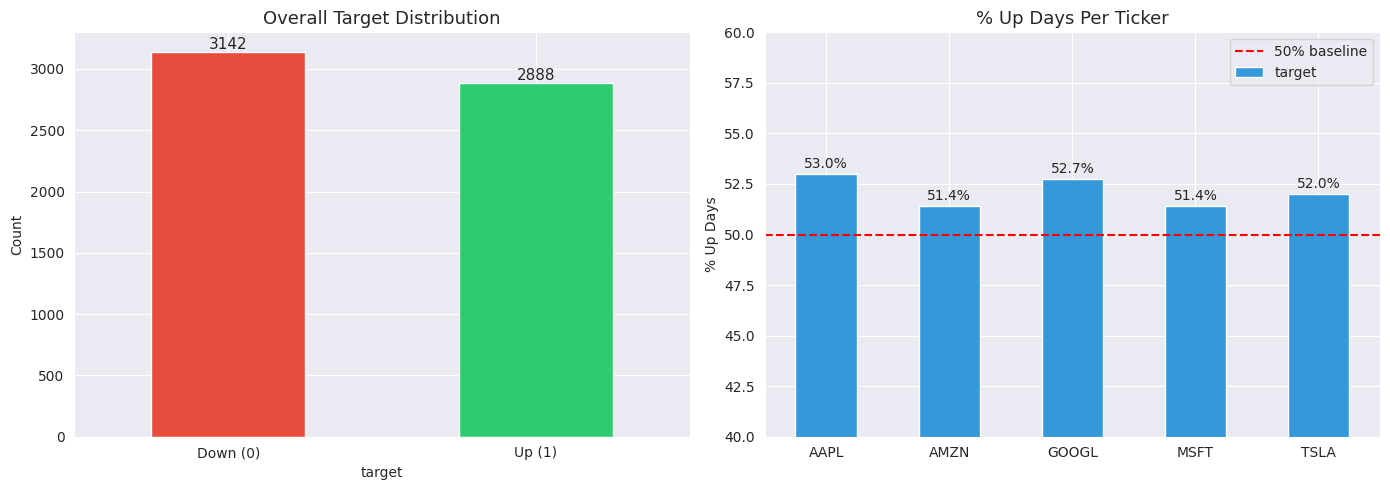

Saved.


In [9]:
# Cell 7: EDA - Target distribution per ticker
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs(PLOTS_PATH, exist_ok=True)
sns.set_style("darkgrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall target distribution
features_df['target'].value_counts().plot(
    kind='bar', color=['#e74c3c', '#2ecc71'],
    ax=axes[0], edgecolor='white')
axes[0].set_title('Overall Target Distribution', fontsize=13)
axes[0].set_xticklabels(['Down (0)', 'Up (1)'], rotation=0)
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2,
                      p.get_height() + 20),
                     ha='center', fontsize=11)

# Per ticker target distribution
ticker_target = features_df.groupby('ticker')['target'].mean() * 100
ticker_target.plot(kind='bar', color='#3498db',
                   ax=axes[1], edgecolor='white')
axes[1].set_title('% Up Days Per Ticker', fontsize=13)
axes[1].set_ylabel('% Up Days')
axes[1].set_xlabel('')
axes[1].set_ylim(40, 60)
axes[1].axhline(50, color='red', linestyle='--',
                linewidth=1.5, label='50% baseline')
axes[1].legend()
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2,
                      p.get_height() + 0.3),
                     ha='center', fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/eda_target_distribution.png', dpi=150)
plt.show()
print("Saved.")

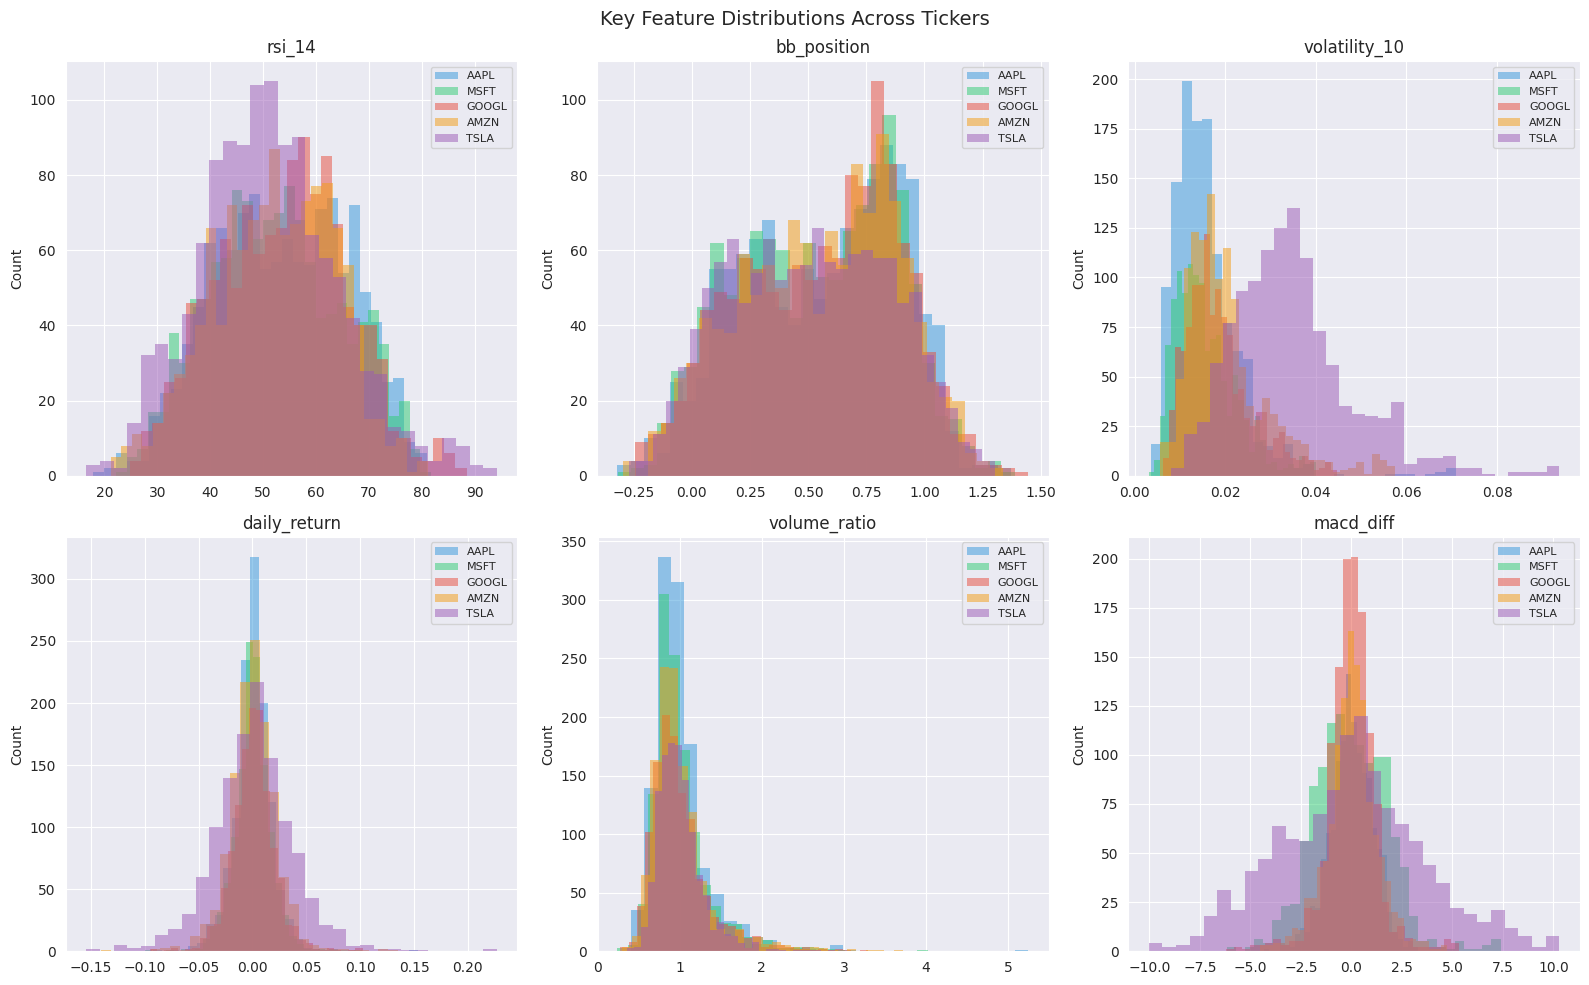

Saved.


In [10]:
# Cell 8: EDA - Compare key feature distributions across tickers
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Key Feature Distributions Across Tickers', fontsize=14)

features_to_plot = ['rsi_14', 'bb_position',
                    'volatility_10', 'daily_return',
                    'volume_ratio', 'macd_diff']

colors = {'AAPL': '#3498db', 'MSFT': '#2ecc71',
          'GOOGL': '#e74c3c', 'AMZN': '#f39c12', 'TSLA': '#9b59b6'}

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 3][idx % 3]
    for ticker in TICKERS:
        subset = features_df[features_df['ticker'] == ticker]
        subset[feature].hist(bins=30, ax=ax, alpha=0.5,
                             label=ticker,
                             color=colors[ticker],
                             edgecolor='none')
    ax.set_title(feature, fontsize=12)
    ax.legend(fontsize=8)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/eda_cross_ticker_features.png', dpi=150)
plt.show()
print("Saved.")

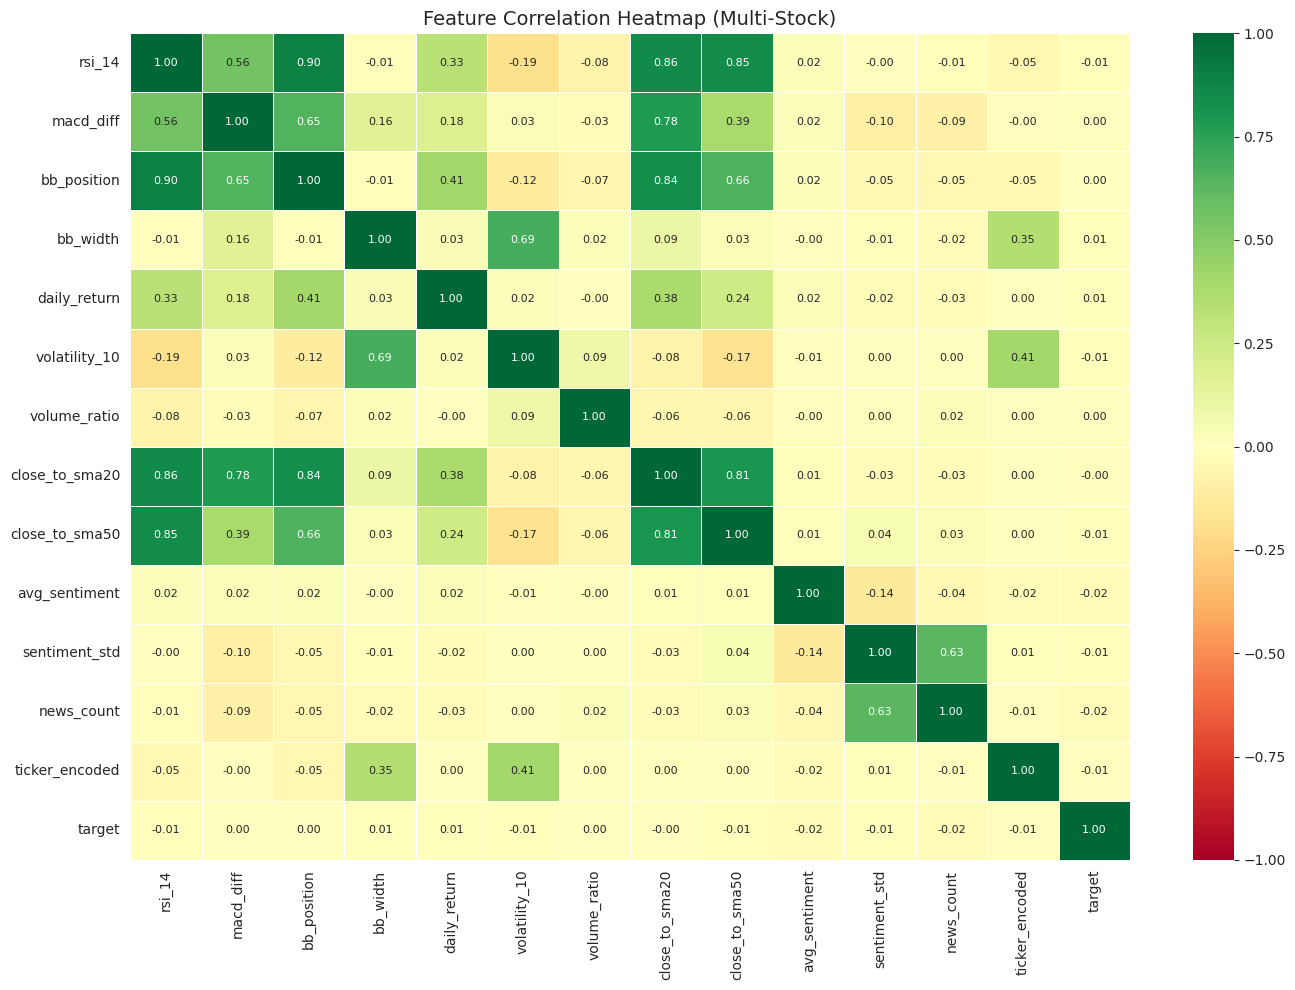

Saved.


In [11]:
# Cell 9: Correlation heatmap of features vs target
corr_features = ['rsi_14', 'macd_diff', 'bb_position',
                 'bb_width', 'daily_return', 'volatility_10',
                 'volume_ratio', 'close_to_sma20',
                 'close_to_sma50', 'avg_sentiment',
                 'sentiment_std', 'news_count',
                 'ticker_encoded', 'target']

corr_matrix = features_df[corr_features].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=ax, annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap (Multi-Stock)',
             fontsize=14)
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/eda_correlation_heatmap.png', dpi=150)
plt.show()
print("Saved.")